# Pandas in 10 Minutes

- This notebook is based on the [Pandas User Guide](https://pandas.pydata.org/pandas-docs/stable/user_guide/10min.html).

In [2]:
import numpy as np

In [3]:
# %pip install pandas    ### comment out after installation
import pandas as pd

In [16]:
# %pip install matplotlib ### comment out after installation
import matplotlib.pyplot as plt

## Basic data structures in pandas

Pandas provides two types of data structures for handling data:

**Series**: a **one-dimensional labeled array** holding data of **any type**
such as integers, strings, Python objects, etc.

**DataFrame**: a **two-dimensional** data structure that holds data like a two-dimension array or a table with rows and columns.

## Object creation
### Series
Creating a Series by passing a **list** of values, letting pandas create a default RangeIndex.

In [17]:
s = pd.Series( [1, 3, 5, np.nan, 6, 8]  )

In [18]:
s

0    1.0
1    3.0
2    5.0
3    NaN
4    6.0
5    8.0
dtype: float64

In [145]:
### check data type
type(df)


pandas.core.frame.DataFrame

### DataFrame from date_range( )

Creating a DataFrame by passing a **NumPy array** with a datetime index using [date_range()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.date_range.html#pandas.date_range) and labeled columns:

In [37]:
### you should check out date_range() by visiting the link provided above; 
### but for now, just observe the behavior of date_range()
### there's a date, and then there's a period parameter with a value of 6 assigned

dates = pd.date_range( "20250901", periods = 6)

In [347]:
### evaluate the object
dates

### You will see that there are 6 dates!!
### often time, these function/object behaviors are well designed by the 
### engineers, but we don't have the time to dig and learn about them just yet
### so, just observe and learn, and use them!

DatetimeIndex(['2025-09-01', '2025-09-02', '2025-09-03', '2025-09-04',
               '2025-09-05', '2025-09-06'],
              dtype='datetime64[ns]', freq='D')

In [348]:
### check the type of the object

type(dates)

pandas.core.indexes.datetimes.DatetimeIndex

### Bigger DataFrame
Now that we know the behavior of the **date_range()** function, let us use it:
- The function np.random.randn( ) generates random numbers from a standard normal (Gaussian) distribution.
- The normal distribution is with a mean (loc) of 0 and a standard deviation (scale) of 1
- Shape: You can pass integer arguments to randn() to specify the dimensions of the output array. For example, np.random.randn(6, 4) will create a 6x4 array of random numbers.
- The **list('ABCD') will output ['A', 'B', 'C', 'D'], which we covered before.

In [126]:
np.random.seed(101)
df = pd.DataFrame(np.random.randn(6, 4), index=dates, columns =list('ABCD'))
df

,A,B,C,D
2025-09-01,2.706850,0.628133,0.907969,0.503826
2025-09-02,0.651118,-0.319318,-0.848077,0.605965
2025-09-03,-2.018168,0.740122,0.528813,-0.589001
2025-09-04,0.188695,-0.758872,-0.933237,0.955057
2025-09-05,0.190794,1.978757,2.605967,0.683509
2025-09-06,0.302665,1.693723,-1.706086,-1.159119


### Dictionary to DataFrame
Now, let us create a DataFrame by passing a **dictionary** of objects:
- where the **keys** are the **column labels** and
- the **values** are the **column values**.

In [127]:
df2 = pd.DataFrame({ 'A': [1., 2, 3, 4],
                     'B': pd.Timestamp('20250925'),     ### different without quote
                     'C': pd.Series(1, index=list(range(4)), dtype='float32'),
                     'D': np.array([3] * 4, dtype='int32'),
                     'E': pd.Categorical( ["test", "train", "test", "train"]),
                     'F':'foo'
                  })

In [128]:
df2

,A,B,C,D,E,F
0,1.0,2025-09-25,1.0,3,test,foo
1,2.0,2025-09-25,1.0,3,train,foo
2,3.0,2025-09-25,1.0,3,test,foo
3,4.0,2025-09-25,1.0,3,train,foo


The columns of the resulting DataFrame have different data types (see: [Pandas **dtype<span style="color:red">s**</span>](https://pandas.pydata.org/pandas-docs/stable/user_guide/basics.html#basics-dtypes)):

In [129]:
df2.dtypes

### note that Pandas automatically assign category and object to E and F

A          float64
B    datetime64[s]
C          float32
D            int32
E         category
F           object
dtype: object

### Tab completion

Tab completion for column names (as well as public attributes) is automatically 
enabled. Here’s a subset of the attributes that will be completed. 

As you can see, the columns A, B, C, and D are automatically tab-completed. E and F are there as well; the rest of the attributes have been truncated for brevity.

In [130]:
%%script echo ""     
### the above line is a magic function to tell Jupyter not to run this cell.

df2.<TAB>

## View data

Use DataFrame.**head()** and DataFrame.**tail()** to view the top and bottom **rows** of the **frame**, respectively:

In [131]:
df.head()     ### note that "df.head" will output a different view

,A,B,C,D
2025-09-01,2.706850,0.628133,0.907969,0.503826
2025-09-02,0.651118,-0.319318,-0.848077,0.605965
2025-09-03,-2.018168,0.740122,0.528813,-0.589001
2025-09-04,0.188695,-0.758872,-0.933237,0.955057
2025-09-05,0.190794,1.978757,2.605967,0.683509


In [132]:
df.tail(3)

,A,B,C,D
2025-09-04,0.188695,-0.758872,-0.933237,0.955057
2025-09-05,0.190794,1.978757,2.605967,0.683509
2025-09-06,0.302665,1.693723,-1.706086,-1.159119


Display the [DataFrame.**index**](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.index.html#pandas.DataFrame.index) or [DataFrame.**columns**](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.columns.html#pandas.DataFrame.columns):

In [133]:
df.index

DatetimeIndex(['2025-09-01', '2025-09-02', '2025-09-03', '2025-09-04',
               '2025-09-05', '2025-09-06'],
              dtype='datetime64[ns]', freq='D')

In [134]:
df.columns

Index(['A', 'B', 'C', 'D'], dtype='object')

Return a NumPy representation of the underlying data with [**DataFrame.to_numpy()**](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.to_numpy.html#pandas.DataFrame.to_numpy) without the index or column labels:

In [142]:
df.to_numpy()

array([[ 2.70684984,  0.62813271,  0.90796945,  0.50382575],
       [ 0.65111795, -0.31931804, -0.84807698,  0.60596535],
       [-2.01816824,  0.74012206,  0.52881349, -0.58900053],
       [ 0.18869531, -0.75887206, -0.93323722,  0.95505651],
       [ 0.19079432,  1.97875732,  2.60596728,  0.68350889],
       [ 0.30266545,  1.69372293, -1.70608593, -1.15911942]])

<div class="alert-info admonition note">
<p class="admonition-title">Note:</p> 
<span style="font-weight:600">NumPy arrays have one dtype for the entire array while pandas DataFrames have one dtype per column</span>. When you call DataFrame.to_numpy(), pandas will find the NumPy dtype that can hold all of the dtypes in the DataFrame. If the common data type is object, DataFrame.to_numpy() will require copying data.
</div>

**describe()** shows a quick **descriptive statistic** summary of your data:

In [143]:
### take a look at the dataframe again:
df

,A,B,C,D
2025-09-01,2.706850,0.628133,0.907969,0.503826
2025-09-02,0.651118,-0.319318,-0.848077,0.605965
2025-09-03,-2.018168,0.740122,0.528813,-0.589001
2025-09-04,0.188695,-0.758872,-0.933237,0.955057
2025-09-05,0.190794,1.978757,2.605967,0.683509
2025-09-06,0.302665,1.693723,-1.706086,-1.159119


In [144]:
df.describe()     ### super useful descriptive stats

,A,B,C,D
count,6.000000,6.000000,6.000000,6.000000
mean,0.336992,0.660424,0.092558,0.166706
std,1.503744,1.075862,1.571280,0.839534
min,-2.018168,-0.758872,-1.706086,-1.159119
25%,0.189220,-0.082455,-0.911947,-0.315794
50%,0.246730,0.684127,-0.159632,0.554896
75%,0.564005,1.455323,0.813180,0.664123
max,2.706850,1.978757,2.605967,0.955057


In [145]:
df.values     ### just like numpy

array([[ 2.70684984,  0.62813271,  0.90796945,  0.50382575],
       [ 0.65111795, -0.31931804, -0.84807698,  0.60596535],
       [-2.01816824,  0.74012206,  0.52881349, -0.58900053],
       [ 0.18869531, -0.75887206, -0.93323722,  0.95505651],
       [ 0.19079432,  1.97875732,  2.60596728,  0.68350889],
       [ 0.30266545,  1.69372293, -1.70608593, -1.15911942]])

Transposing your data:

An super easy example of trasposing:

In [161]:
lst = list(range(9))
arr = np.array(lst).reshape(3, 3)
df3 = pd.DataFrame(arr)
df3

,0,1,2
0,0,1,2
1,3,4,5
2,6,7,8


In [162]:
df3.T

,0,1,2
0,0,3,6
1,1,4,7
2,2,5,8


Now get back to df:

In [163]:
df

,A,B,C,D
2025-09-01,2.706850,0.628133,0.907969,0.503826
2025-09-02,0.651118,-0.319318,-0.848077,0.605965
2025-09-03,-2.018168,0.740122,0.528813,-0.589001
2025-09-04,0.188695,-0.758872,-0.933237,0.955057
2025-09-05,0.190794,1.978757,2.605967,0.683509
2025-09-06,0.302665,1.693723,-1.706086,-1.159119


In [165]:
### transpose df
df.T

,2025-09-01,2025-09-02,2025-09-03,2025-09-04,2025-09-05,2025-09-06
A,2.706850,0.651118,-2.018168,0.188695,0.190794,0.302665
B,0.628133,-0.319318,0.740122,-0.758872,1.978757,1.693723
C,0.907969,-0.848077,0.528813,-0.933237,2.605967,-1.706086
D,0.503826,0.605965,-0.589001,0.955057,0.683509,-1.159119


[DataFrame.sort_index()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.sort_index.html#pandas.DataFrame.sort_index) sorts by an axis:

In [171]:
### axis 1 is the columns; axis 0 is the rows
df.sort_index(axis=1, ascending=False)

,D,C,B,A
2025-09-01,0.503826,0.907969,0.628133,2.706850
2025-09-02,0.605965,-0.848077,-0.319318,0.651118
2025-09-03,-0.589001,0.528813,0.740122,-2.018168
2025-09-04,0.955057,-0.933237,-0.758872,0.188695
2025-09-05,0.683509,2.605967,1.978757,0.190794
2025-09-06,-1.159119,-1.706086,1.693723,0.302665


In [175]:
### sorting by axis 1, ascending
df.sort_index(axis=1, ascending=True)

,A,B,C,D
2025-09-01,2.706850,0.628133,0.907969,0.503826
2025-09-02,0.651118,-0.319318,-0.848077,0.605965
2025-09-03,-2.018168,0.740122,0.528813,-0.589001
2025-09-04,0.188695,-0.758872,-0.933237,0.955057
2025-09-05,0.190794,1.978757,2.605967,0.683509
2025-09-06,0.302665,1.693723,-1.706086,-1.159119


In [182]:
### sorting by values
df.sort_values(by='B')

,A,B,C,D
2025-09-04,0.188695,-0.758872,-0.933237,0.955057
2025-09-02,0.651118,-0.319318,-0.848077,0.605965
2025-09-01,2.706850,0.628133,0.907969,0.503826
2025-09-03,-2.018168,0.740122,0.528813,-0.589001
2025-09-06,0.302665,1.693723,-1.706086,-1.159119
2025-09-05,0.190794,1.978757,2.605967,0.683509


## Selection

**Note**: While standard Python/NumPy expressions for selecting and setting are intuitive and come in handy for interactive work, for production code, we recommend the optimized pandas data access methods, DataFrame.at(), DataFrame.iat(), DataFrame.loc() and DataFrame.iloc().

In [186]:
### check df first
df

,A,B,C,D
2025-09-01,2.706850,0.628133,0.907969,0.503826
2025-09-02,0.651118,-0.319318,-0.848077,0.605965
2025-09-03,-2.018168,0.740122,0.528813,-0.589001
2025-09-04,0.188695,-0.758872,-0.933237,0.955057
2025-09-05,0.190794,1.978757,2.605967,0.683509
2025-09-06,0.302665,1.693723,-1.706086,-1.159119


### Getitem ( [ ] )

#### Single column: passing in label
For a DataFrame, passing a single **label** selects a column and yields a **Series** equivalent to `df.A`:



In [211]:
df['A']

### you get the indices and the selected column

2025-09-01    2.706850
2025-09-02    0.651118
2025-09-03   -2.018168
2025-09-04    0.188695
2025-09-05    0.190794
2025-09-06    0.302665
Freq: D, Name: A, dtype: float64

For a DataFrame, passing a slice `:` selects matching rows:

#### Use slice notation: Row index

In [212]:
df[0:3]

,A,B,C,D
2025-09-01,2.706850,0.628133,0.907969,0.503826
2025-09-02,0.651118,-0.319318,-0.848077,0.605965
2025-09-03,-2.018168,0.740122,0.528813,-0.589001


#### Use slice notation: Labels
For custom labels, slicing/getitem behaves like .loc (stop is inclusive).

In [213]:
df['20250902':'2025-09-04']

,A,B,C,D
2025-09-02,0.651118,-0.319318,-0.848077,0.605965
2025-09-03,-2.018168,0.740122,0.528813,-0.589001
2025-09-04,0.188695,-0.758872,-0.933237,0.955057


### Selection by label

See more in [Selection by Label](https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#indexing-label) using [DataFrame.loc( )](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.loc.html#pandas.DataFrame.loc) or [DataFrame.at( )](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.at.html#pandas.DataFrame.at).

- DataFrame.**loc**: Access a group of rows and columns by label(s) or a boolean array. Allows inputs:
  - single label (Note this returns the row as a Series.)
  - list or array of labels
  - slice object with labels
- DataFrame.**at**: Access a single value for a row/column label pair. .at does label-based lookups. Use at if you only need to get or set a single value in a DataFrame or Series.

Selecting a row matching a label:

In [217]:
### check df
df

,A,B,C,D
2025-09-01,2.706850,0.628133,0.907969,0.503826
2025-09-02,0.651118,-0.319318,-0.848077,0.605965
2025-09-03,-2.018168,0.740122,0.528813,-0.589001
2025-09-04,0.188695,-0.758872,-0.933237,0.955057
2025-09-05,0.190794,1.978757,2.605967,0.683509
2025-09-06,0.302665,1.693723,-1.706086,-1.159119


Selecting a row matching a label. Note this returns the row as a Series.



In [231]:
df.loc[dates[0]]

A    2.706850
B    0.628133
C    0.907969
D    0.503826
Name: 2025-09-01 00:00:00, dtype: float64

Select all rows (`:`) with a select column labels:

In [241]:
### all the rows (axis 0) and a list of column labels
df.loc[:, ['A', 'B']]

,A,B
2025-09-01,2.706850,0.628133
2025-09-02,0.651118,-0.319318
2025-09-03,-2.018168,0.740122
2025-09-04,0.188695,-0.758872
2025-09-05,0.190794,1.978757
2025-09-06,0.302665,1.693723


For label slicing, both endpoints are included:

In [238]:
df.loc['20250902' : '20250904', ['A', 'B']]

,A,B
2025-09-02,0.651118,-0.319318
2025-09-03,-2.018168,0.740122
2025-09-04,0.188695,-0.758872


Selecting a single row and column label returns a scalar:

In [242]:
df.loc[dates[0], 'A']

np.float64(2.706849839399938)

For getting fast access to a scalar (equivalent to the prior method):

In [243]:
df.at[dates[0],'A']

np.float64(2.706849839399938)

## Selection by position

See more in [Selection by Position](https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#indexing-integer) using [DataFrame.iloc()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.iloc.html#pandas.DataFrame.iloc) or [DataFrame.iat()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.iat.html#pandas.DataFrame.iat).

Select via the position of the passed integers:

In [249]:
### check df
df

,A,B,C,D
2025-09-01,2.706850,0.628133,0.907969,0.503826
2025-09-02,0.651118,-0.319318,-0.848077,0.605965
2025-09-03,-2.018168,0.740122,0.528813,-0.589001
2025-09-04,0.188695,-0.758872,-0.933237,0.955057
2025-09-05,0.190794,1.978757,2.605967,0.683509
2025-09-06,0.302665,1.693723,-1.706086,-1.159119


In [245]:
df.iloc[3]

A    0.188695
B   -0.758872
C   -0.933237
D    0.955057
Name: 2025-09-04 00:00:00, dtype: float64

Integer slices acts similar to NumPy/Python:

In [246]:
df.iloc[3:5, 0:2]

,A,B
2025-09-04,0.188695,-0.758872
2025-09-05,0.190794,1.978757


Lists of integer position locations:

In [248]:
df.iloc[[1, 2, 4], [0, 2]]

,A,C
2025-09-02,0.651118,-0.848077
2025-09-03,-2.018168,0.528813
2025-09-05,0.190794,2.605967


In [307]:
### NumPy fancy indexing is similar to iloc
lst = list(range(20))
arr = np.array(lst).reshape(5, 4)
print(arr)
### fancy indexing
print("specific rows:", arr[ [0, 2, 4] ])
print("sepcific scalars:", arr[ [0, 2, 4], [1, 2, 3] ])   ### pairs ofo row & column indices

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]
 [16 17 18 19]]
specific rows: [[ 0  1  2  3]
 [ 8  9 10 11]
 [16 17 18 19]]
sepcific scalars: [ 1 10 19]


For slicing rows explicitly:

In [308]:
df.iloc[1:3, :]

,A,B,C,D
2025-09-02,0.651118,-0.319318,-0.848077,0.605965
2025-09-03,-2.018168,0.740122,0.528813,-0.589001


For slicing columns explicitly:

In [309]:
df.iloc[:, 1:3]

,B,C
2025-09-01,0.628133,0.907969
2025-09-02,-0.319318,-0.848077
2025-09-03,0.740122,0.528813
2025-09-04,-0.758872,-0.933237
2025-09-05,1.978757,2.605967
2025-09-06,1.693723,-1.706086


For getting a value explicitly:

In [310]:
df.iloc[1, 1]

np.float64(-0.31931804459303326)

For getting fast access to a scalar (equivalent to the prior method):

In [311]:
df.iat[1, 1]

np.float64(-0.31931804459303326)

## Boolean indexing

Select rows where `df.A` is greater than `0`.

In [314]:
df[df["A"] > 0]

,A,B,C,D
2025-09-01,2.706850,0.628133,0.907969,0.503826
2025-09-02,0.651118,-0.319318,-0.848077,0.605965
2025-09-04,0.188695,-0.758872,-0.933237,0.955057
2025-09-05,0.190794,1.978757,2.605967,0.683509
2025-09-06,0.302665,1.693723,-1.706086,-1.159119


Selecting values from a DataFrame where a boolean condition is met:

In [315]:
df[df > 0]

,A,B,C,D
2025-09-01,2.706850,0.628133,0.907969,0.503826
2025-09-02,0.651118,NaN,NaN,0.605965
2025-09-03,NaN,0.740122,0.528813,NaN
2025-09-04,0.188695,NaN,NaN,0.955057
2025-09-05,0.190794,1.978757,2.605967,0.683509
2025-09-06,0.302665,1.693723,NaN,NaN


Using [isin()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.isin.html#pandas.Series.isin) method for filtering:

In [318]:
df2 = df.copy()
df2["E"] = [ "one", "one", "two", "three", "four", "three"]
df2

,A,B,C,D,E
2025-09-01,2.706850,0.628133,0.907969,0.503826,one
2025-09-02,0.651118,-0.319318,-0.848077,0.605965,one
2025-09-03,-2.018168,0.740122,0.528813,-0.589001,two
2025-09-04,0.188695,-0.758872,-0.933237,0.955057,three
2025-09-05,0.190794,1.978757,2.605967,0.683509,four
2025-09-06,0.302665,1.693723,-1.706086,-1.159119,three


In [320]:
df2[df2["E"].isin(["two", "four"])]

,A,B,C,D,E
2025-09-03,-2.018168,0.740122,0.528813,-0.589001,two
2025-09-05,0.190794,1.978757,2.605967,0.683509,four


## Setting
Setting a new column automatically aligns the data by the indexes:

In [363]:
### note that the date_range does not align with df

s1 = pd.Series([1, 2, 3, 4, 5, 6], index = pd.date_range("20250902", periods=6))

In [364]:
s1

2025-09-02    1
2025-09-03    2
2025-09-04    3
2025-09-05    4
2025-09-06    5
2025-09-07    6
Freq: D, dtype: int64

In [365]:
### observe how the new column aligns the data by the indexes

df["F"] = s1

In [366]:
df

,A,B,C,D,F
2025-09-01,0.000000,0.000000,0.907969,5.0,NaN
2025-09-02,0.651118,-0.319318,-0.848077,5.0,1.0
2025-09-03,-2.018168,0.740122,0.528813,5.0,2.0
2025-09-04,0.188695,-0.758872,-0.933237,5.0,3.0
2025-09-05,0.190794,1.978757,2.605967,5.0,4.0
2025-09-06,0.302665,1.693723,-1.706086,5.0,5.0


Setting values by label:

In [367]:
df.at[dates[0], "A"] = 0

Setting values by position:

In [368]:
df.iat[0, 1] = 0

In [369]:
df.at[dates[0], "A"] = 0

Setting by assigning with a NumPy array:

In [370]:
df.loc[:, "D"] = np.array([5] * len(df))

In [371]:
### in case you have questions about the above column operation
np.array([5] * len(df))

array([5, 5, 5, 5, 5, 5])

The resutl of the prior setting operations:

In [372]:
df

,A,B,C,D,F
2025-09-01,0.000000,0.000000,0.907969,5.0,NaN
2025-09-02,0.651118,-0.319318,-0.848077,5.0,1.0
2025-09-03,-2.018168,0.740122,0.528813,5.0,2.0
2025-09-04,0.188695,-0.758872,-0.933237,5.0,3.0
2025-09-05,0.190794,1.978757,2.605967,5.0,4.0
2025-09-06,0.302665,1.693723,-1.706086,5.0,5.0


A `where` operation with setting:

In [373]:
df2 = df.copy()
df2[df2 > 0 ]= -df2
df2

,A,B,C,D,F
2025-09-01,0.000000,0.000000,-0.907969,-5.0,NaN
2025-09-02,-0.651118,-0.319318,-0.848077,-5.0,-1.0
2025-09-03,-2.018168,-0.740122,-0.528813,-5.0,-2.0
2025-09-04,-0.188695,-0.758872,-0.933237,-5.0,-3.0
2025-09-05,-0.190794,-1.978757,-2.605967,-5.0,-4.0
2025-09-06,-0.302665,-1.693723,-1.706086,-5.0,-5.0


## Missing data

For NumPy data types, `np.nan` represents missing data. It is by default not included in computations. See the [Missing Data section](https://pandas.pydata.org/pandas-docs/stable/user_guide/missing_data.html#missing-data).

Reindexing (**reindex( )**) allows you to change/add/delete the index on a specified axis. This returns a copy of the data:

In [374]:
df1 = df.reindex(index=dates[0:4], columns=list(df.columns) + ["E"])
df1.loc[dates[0] : dates[1], "E"] = 1
df1


,A,B,C,D,F,E
2025-09-01,0.000000,0.000000,0.907969,5.0,NaN,1.0
2025-09-02,0.651118,-0.319318,-0.848077,5.0,1.0,1.0
2025-09-03,-2.018168,0.740122,0.528813,5.0,2.0,NaN
2025-09-04,0.188695,-0.758872,-0.933237,5.0,3.0,NaN


[DataFrame.**dropna( )**](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.dropna.html#pandas.DataFrame.dropna) drops any rows that have missing data:

In [382]:
df1.dropna(how="any")

### only one row left that does not have missing data

,A,B,C,D,F,E
2025-09-02,0.651118,-0.319318,-0.848077,5.0,1.0,1.0


[DataFrame.**fillna( )**](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.fillna.html#pandas.DataFrame.fillna) fills missing data:

In [383]:
df1.fillna(value=5)

,A,B,C,D,F,E
2025-09-01,0.000000,0.000000,0.907969,5.0,5.0,1.0
2025-09-02,0.651118,-0.319318,-0.848077,5.0,1.0,1.0
2025-09-03,-2.018168,0.740122,0.528813,5.0,2.0,5.0
2025-09-04,0.188695,-0.758872,-0.933237,5.0,3.0,5.0


[**isna( )**](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.isna.html#pandas.isna) gets the boolean mask where values are `nan`:

In [384]:
pd.isna(df1)

,A,B,C,D,F,E
2025-09-01,False,False,False,False,True,False
2025-09-02,False,False,False,False,False,False
2025-09-03,False,False,False,False,False,True
2025-09-04,False,False,False,False,False,True


## Operations

See the [Basic section on Binary Ops](https://pandas.pydata.org/pandas-docs/stable/user_guide/basics.html#basics-binop).

### Stats

- Operations in general **exclude** missing data.

Calculate the mean value for each column:

In [391]:
print(df, "\n")
print(df.mean())

                   A         B         C    D    F
2025-09-01  0.000000  0.000000  0.907969  5.0  NaN
2025-09-02  0.651118 -0.319318 -0.848077  5.0  1.0
2025-09-03 -2.018168  0.740122  0.528813  5.0  2.0
2025-09-04  0.188695 -0.758872 -0.933237  5.0  3.0
2025-09-05  0.190794  1.978757  2.605967  5.0  4.0
2025-09-06  0.302665  1.693723 -1.706086  5.0  5.0 

A   -0.114149
B    0.555735
C    0.092558
D    5.000000
F    3.000000
dtype: float64


Calculate the mean value for each row:

In [392]:
df.mean(axis=1)

2025-09-01    1.476992
2025-09-02    1.096745
2025-09-03    1.250153
2025-09-04    1.299317
2025-09-05    2.755104
2025-09-06    2.058060
Freq: D, dtype: float64

Operating with another [Series](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.html#pandas.Series) or [DataFrame](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.html#pandas.DataFrame) with a different index or column will align the result with the union of the index or column labels. In addition, pandas automatically broadcasts along the specified dimension and will fill unaligned labels with `np.nan`.

In [401]:
### shift() shifts the values of a Series or DataFrame along a 
### specified axis by a given number of periods.

s = pd.Series([1, 3, 5, np.nan, 6, 8], index=dates).shift(periods=2)
s

2025-09-01    NaN
2025-09-02    NaN
2025-09-03    1.0
2025-09-04    3.0
2025-09-05    5.0
2025-09-06    NaN
Freq: D, dtype: float64

In [407]:
print(df, "\n")
print(df.sub(s, axis="index"))

### sub() calculates the difference between corresponding elements 
### of the DataFrame and the other object. *broadcasting

                   A         B         C    D    F
2025-09-01  0.000000  0.000000  0.907969  5.0  NaN
2025-09-02  0.651118 -0.319318 -0.848077  5.0  1.0
2025-09-03 -2.018168  0.740122  0.528813  5.0  2.0
2025-09-04  0.188695 -0.758872 -0.933237  5.0  3.0
2025-09-05  0.190794  1.978757  2.605967  5.0  4.0
2025-09-06  0.302665  1.693723 -1.706086  5.0  5.0 

                   A         B         C    D    F
2025-09-01       NaN       NaN       NaN  NaN  NaN
2025-09-02       NaN       NaN       NaN  NaN  NaN
2025-09-03 -3.018168 -0.259878 -0.471187  4.0  1.0
2025-09-04 -2.811305 -3.758872 -3.933237  2.0  0.0
2025-09-05 -4.809206 -3.021243 -2.394033  0.0 -1.0
2025-09-06       NaN       NaN       NaN  NaN  NaN


## User defined functions

In [405]:
0.190794 - 5

-4.809206

In [360]:
ts = pd.Series(np.random.randn(10), index=pd.date_range('1/1/2000', periods=10))


In [361]:
ts.describe

<bound method NDFrame.describe of 2000-01-01   -0.134841
2000-01-02    0.390528
2000-01-03    0.166905
2000-01-04    0.184502
2000-01-05    0.807706
2000-01-06    0.072960
2000-01-07    0.638787
2000-01-08    0.329646
2000-01-09   -0.497104
2000-01-10   -0.754070
Freq: D, dtype: float64>

<Axes: >

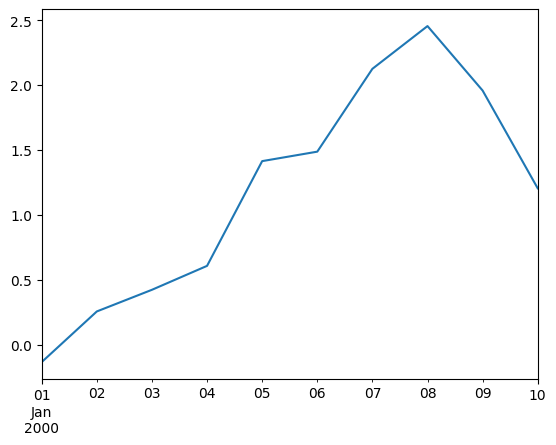

In [362]:
ts = ts.cumsum()
ts.plot()

In [102]:
ts.mean()

-2.8877381261129167

In [103]:
print('hello, world')

hello, world


In [104]:
import time

In [111]:
time.ctime()

'Sun Dec 16 18:22:35 2018'